<a href="https://colab.research.google.com/github/LocoBunny04/ACMP2000-Data-ML/blob/main/Kawinthida_Haase_Network_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# First steps: loading and visualizing a small network

We will use the `networkx` library, an industry standard for network analysis, and matplotlib for visualization.

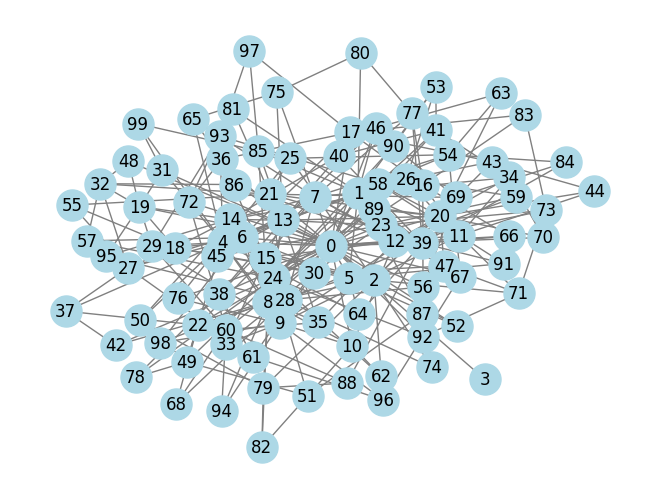

In [8]:
import networkx as nx
import matplotlib.pyplot as plt
import random

# Scale-free network
scale_free_G = nx.barabasi_albert_graph(100, 3, seed=1)
# Drawing graph
pos = nx.spring_layout(scale_free_G, seed=1)
nx.draw(scale_free_G, pos, with_labels=True, node_color='lightblue',
        node_size=500, edge_color='gray')


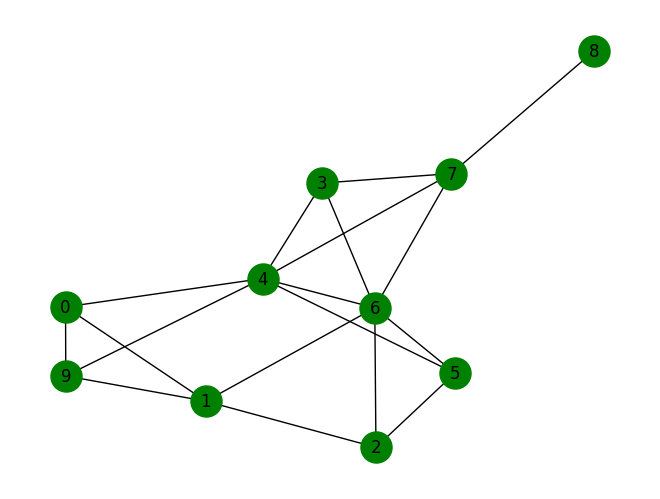

In [11]:
# Random Graph

# Adding Random Graph
n = 10 # number of nodes
p = 0.3 # probability of an edge between pairs of nodes
random_G = nx.erdos_renyi_graph(n, p, seed=1)

pos = nx.spring_layout(random_G, seed=1)
nx.draw(random_G, pos, with_labels=True, node_color='Green', node_size=500,
        edge_color='black')

# Simulating Attack

291
313


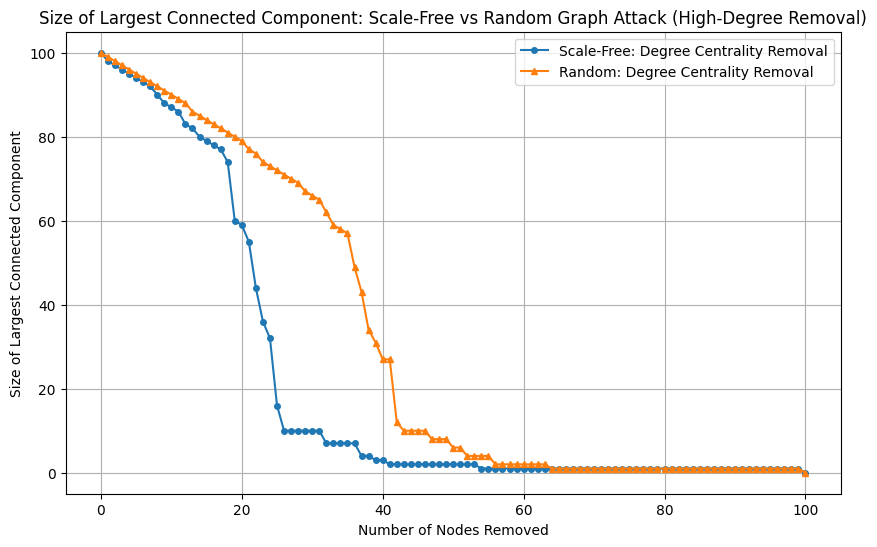

In [15]:
import random
import networkx as nx
import matplotlib.pyplot as plt

# create a Barabási-Albert scale-free graph
scale_free_G = nx.barabasi_albert_graph(100, 3, seed=1)
print(scale_free_G.number_of_edges())

# create a random graph
random_G = nx.erdos_renyi_graph(100, 0.06, seed=1)
print(random_G.number_of_edges())

# get the initial size of the largest connected component
initial_lcc_size_sf = len(max(nx.connected_components(scale_free_G), key=len))
initial_lcc_size_rand = len(max(nx.connected_components(random_G), key=len))

# prepare lists to store LCC sizes
lcc_sizes_sf_degree = [initial_lcc_size_sf]
lcc_sizes_rand_degree = [initial_lcc_size_rand]

# initialize counters for tracking node removal
i = 0

num_nodes_sf = len(scale_free_G)
num_nodes_rand = len(random_G)

# remove nodes in parallel from both networks using high-degree node removal
while i < max(num_nodes_sf, num_nodes_rand):

    # sort nodes by degree in descending order for scale-free graph
    if len(scale_free_G) > 0:
        nodes_sorted_by_degree_sf = sorted(scale_free_G.degree, key=lambda x: x[1],
                                           reverse=True)
        # high-degree node removal from scale_free_G
        node_to_remove_sf = nodes_sorted_by_degree_sf[0][0]
        scale_free_G.remove_node(node_to_remove_sf)
        # check largest connected component size after removal
        if len(scale_free_G) > 0:
            largest_cc_sf_degree = max(nx.connected_components(scale_free_G),
                                       key=len)
            lcc_sizes_sf_degree.append(len(largest_cc_sf_degree))
        else:
            lcc_sizes_sf_degree.append(0) # Append 0 if graph is empty


    # sort nodes by degree in descending order for random graph
    if len(random_G) > 0:
         nodes_sorted_by_degree_rand = sorted(random_G.degree, key=lambda x: x[1],
                                           reverse=True)
         # high-degree node removal from random_G
         node_to_remove_rand = nodes_sorted_by_degree_rand[0][0]
         random_G.remove_node(node_to_remove_rand)
         # check largest connected component size after removal
         if len(random_G) > 0:
             largest_cc_rand_degree = max(nx.connected_components(random_G), key=len)
             lcc_sizes_rand_degree.append(len(largest_cc_rand_degree))
         else:
            lcc_sizes_rand_degree.append(0) # Append 0 if graph is empty

    i += 1


# plot the results
plt.figure(figsize=(10, 6))
plt.plot(range(len(lcc_sizes_sf_degree)), lcc_sizes_sf_degree,
         label='Scale-Free: Degree Centrality Removal', marker='o', linestyle='-', markersize=4)
plt.plot(range(len(lcc_sizes_rand_degree)), lcc_sizes_rand_degree,
         label='Random: Degree Centrality Removal', marker='^', linestyle='-', markersize=4)

plt.title("Size of Largest Connected Component: Scale-Free vs Random Graph Attack (High-Degree Removal)")
plt.xlabel("Number of Nodes Removed")
plt.ylabel("Size of Largest Connected Component")
plt.legend()
plt.grid(True)
plt.show()

291
313


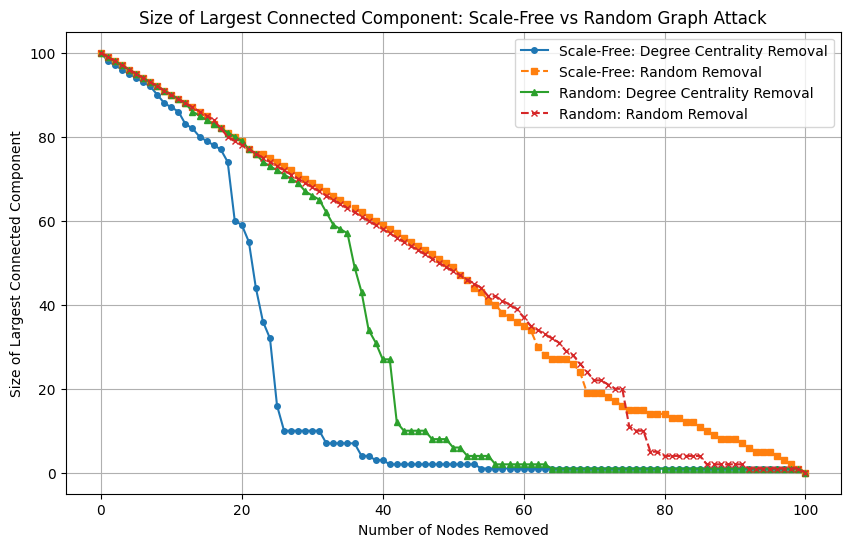

In [14]:
import random

# create a Barabási-Albert scale-free graph
scale_free_G = nx.barabasi_albert_graph(100, 3, seed=1)
print(scale_free_G.number_of_edges())

# create a random graph
random_G = nx.erdos_renyi_graph(100, 0.06, seed=1)
print(random_G.number_of_edges())

# create copies of the graphs for random removal
scale_free_G_random = scale_free_G.copy()
random_G_random = random_G.copy()

# get the initial size of the largest connected component
initial_lcc_size_sf = len(max(nx.connected_components(scale_free_G), key=len))
initial_lcc_size_rand = len(max(nx.connected_components(random_G), key=len))

# prepare lists to store LCC sizes
lcc_sizes_sf_degree = [initial_lcc_size_sf]
lcc_sizes_rand_degree = [initial_lcc_size_rand]
lcc_sizes_sf_random = [initial_lcc_size_sf]
lcc_sizes_rand_random = [initial_lcc_size_rand]

# randomize the nodes for random removal
random_nodes_sf = list(scale_free_G_random.nodes())
random.shuffle(random_nodes_sf)

random_nodes_rand = list(random_G_random.nodes())
random.shuffle(random_nodes_rand)

# initialize counters for tracking node removal
i = 0

num_nodes_sf = len(scale_free_G)
num_nodes_rand = len(random_G)

# remove nodes in parallel from both networks (degree and random removal)
while i < max(num_nodes_sf, num_nodes_rand):

    # sort nodes by degree in descending order for scale-free graph
    if len(scale_free_G) > 0:
        nodes_sorted_by_degree_sf = sorted(scale_free_G.degree, key=lambda x: x[1],
                                           reverse=True)
        # high-degree node removal from scale_free_G
        node_to_remove_sf = nodes_sorted_by_degree_sf[0][0]
        scale_free_G.remove_node(node_to_remove_sf)
        # check largest connected component size after removal
        if len(scale_free_G) > 0:
            largest_cc_sf_degree = max(nx.connected_components(scale_free_G),
                                       key=len)
            lcc_sizes_sf_degree.append(len(largest_cc_sf_degree))
        else:
            lcc_sizes_sf_degree.append(0) # Append 0 if graph is empty


    # sort nodes by degree in descending order for random graph
    if len(random_G) > 0:
         nodes_sorted_by_degree_rand = sorted(random_G.degree, key=lambda x: x[1],
                                           reverse=True)
         # high-degree node removal from random_G
         node_to_remove_rand = nodes_sorted_by_degree_rand[0][0]
         random_G.remove_node(node_to_remove_rand)
         # check largest connected component size after removal
         if len(random_G) > 0:
             largest_cc_rand_degree = max(nx.connected_components(random_G), key=len)
             lcc_sizes_rand_degree.append(len(largest_cc_rand_degree))
         else:
            lcc_sizes_rand_degree.append(0) # Append 0 if graph is empty


    # random node removal from scale_free_G_random
    if i < len(random_nodes_sf):
        random_node_to_remove_sf = random_nodes_sf[i]
        scale_free_G_random.remove_node(random_node_to_remove_sf)
        # check largest connected component size after removal
        if len(scale_free_G_random) > 0:
            largest_cc_sf_random = max(nx.connected_components(scale_free_G_random), key=len)
            lcc_sizes_sf_random.append(len(largest_cc_sf_random))
        else:
            lcc_sizes_sf_random.append(0) # Append 0 if graph is empty


    # random node removal from random_G_random
    if i < len(random_nodes_rand):
        random_node_to_remove_rand = random_nodes_rand[i]
        random_G_random.remove_node(random_node_to_remove_rand)
        # check largest connected component size after removal
        if len(random_G_random) > 0:
            largest_cc_rand_random = max(nx.connected_components(random_G_random), key=len)
            lcc_sizes_rand_random.append(len(largest_cc_rand_random))
        else:
            lcc_sizes_rand_random.append(0) # Append 0 if graph is empty

    i += 1


# plot the results
plt.figure(figsize=(10, 6))
plt.plot(range(len(lcc_sizes_sf_degree)), lcc_sizes_sf_degree,
         label='Scale-Free: Degree Centrality Removal', marker='o', linestyle='-', markersize=4)
plt.plot(range(len(lcc_sizes_sf_random)), lcc_sizes_sf_random,
         label='Scale-Free: Random Removal', marker='s', linestyle='--', markersize=4)
plt.plot(range(len(lcc_sizes_rand_degree)), lcc_sizes_rand_degree,
         label='Random: Degree Centrality Removal', marker='^', linestyle='-', markersize=4)
plt.plot(range(len(lcc_sizes_rand_random)), lcc_sizes_rand_random,
         label='Random: Random Removal', marker='x', linestyle='--', markersize=4)

plt.title("Size of Largest Connected Component: Scale-Free vs Random Graph Attack")
plt.xlabel("Number of Nodes Removed")
plt.ylabel("Size of Largest Connected Component")
plt.legend()
plt.grid(True)
plt.show()